## species eda
gbif species list (inaturalist research-grade, flowering plants) -> pick species to download

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/gbif_species_list.csv", sep="\t")
print(len(df))
df.head()

157673


,taxonKey,scientificName,acceptedTaxonKey,acceptedScientificName,numberOfOccurrences,taxonRank,taxonomicStatus,kingdom,kingdomKey,phylum,...,classKey,order,orderKey,family,familyKey,genus,genusKey,species,speciesKey,iucnRedListCategory
0,2767415,Scilla verna Huds.,2767415,Scilla verna Huds.,2016,SPECIES,ACCEPTED,Plantae,6,Tracheophyta,...,196.0,Asparagales,1169.0,Asparagaceae,7683.0,Scilla,9555189.0,Scilla verna,2767415.0,NaN
1,3033520,Clematis occidentalis (Hornem.) DC.,3033520,Clematis occidentalis (Hornem.) DC.,4235,SPECIES,ACCEPTED,Plantae,6,Tracheophyta,...,220.0,Ranunculales,399.0,Ranunculaceae,2410.0,Clematis,3033512.0,Clematis occidentalis,3033520.0,NaN
2,2925531,Verbena stricta Vent.,2925531,Verbena stricta Vent.,9508,SPECIES,ACCEPTED,Plantae,6,Tracheophyta,...,220.0,Lamiales,408.0,Verbenaceae,6689.0,Verbena,2925470.0,Verbena stricta,2925531.0,NaN
3,6312126,Elegia ebracteata (Kunth) Moline & H.P.Linder,6312126,Elegia ebracteata (Kunth) Moline & H.P.Linder,107,SPECIES,ACCEPTED,Plantae,6,Tracheophyta,...,196.0,Poales,1369.0,Restionaceae,4213.0,Elegia,2707472.0,Elegia ebracteata,6312126.0,NaN
4,7430494,Gaultheria crassa Allan,7430494,Gaultheria crassa Allan,1157,SPECIES,ACCEPTED,Plantae,6,Tracheophyta,...,220.0,Ericales,1353.0,Ericaceae,2505.0,Gaultheria,2882751.0,Gaultheria crassa,7430494.0,NaN


In [3]:
df[["taxonRank","taxonomicStatus"]].value_counts()

taxonRank   taxonomicStatus       
SPECIES     ACCEPTED                  129573
SUBSPECIES  ACCEPTED                    9714
SPECIES     SYNONYM                     6281
VARIETY     ACCEPTED                    6139
GENUS       ACCEPTED                    2078
VARIETY     SYNONYM                     1686
SUBSPECIES  SYNONYM                     1551
SPECIES     PROVISIONALLY_ACCEPTED       169
GENUS       SYNONYM                      152
FORM        SYNONYM                       74
FAMILY      ACCEPTED                      73
FORM        ACCEPTED                      60
VARIETY     PROVISIONALLY_ACCEPTED        52
GENUS       PROVISIONALLY_ACCEPTED        32
FAMILY      SYNONYM                       15
SUBSPECIES  PROVISIONALLY_ACCEPTED        11
SPECIES     AMBIGUOUS_SYNONYM              7
FORM        AMBIGUOUS_SYNONYM              2
ORDER       ACCEPTED                       1
GENUS       AMBIGUOUS_SYNONYM              1
SUBSPECIES  AMBIGUOUS_SYNONYM              1
VARIETY     AMBIGUOU

In [4]:
# keep accepted species only, drop subspecies/varieties/synonyms
sp = df[(df["taxonRank"]=="SPECIES") & (df["taxonomicStatus"]=="ACCEPTED") & df["species"].notna()].copy()
sp["speciesKey"] = sp["speciesKey"].astype("Int64")  # was float from blank genus/family rows

print(len(sp), "species")
print(sp["numberOfOccurrences"].sum(), "observations")
print(sp["family"].nunique(), "families,", sp["genus"].nunique(), "genera")

129573 species
51024040 observations
453 families, 10809 genera


In [5]:
sp["numberOfOccurrences"].describe(percentiles=[.5,.75,.9,.95,.99]).round(1)

count    129573.0
mean        393.8
std        3063.5
min           1.0
50%          10.0
75%          59.0
90%         360.0
95%        1066.0
99%        7814.1
max      186173.0
Name: numberOfOccurrences, dtype: float64

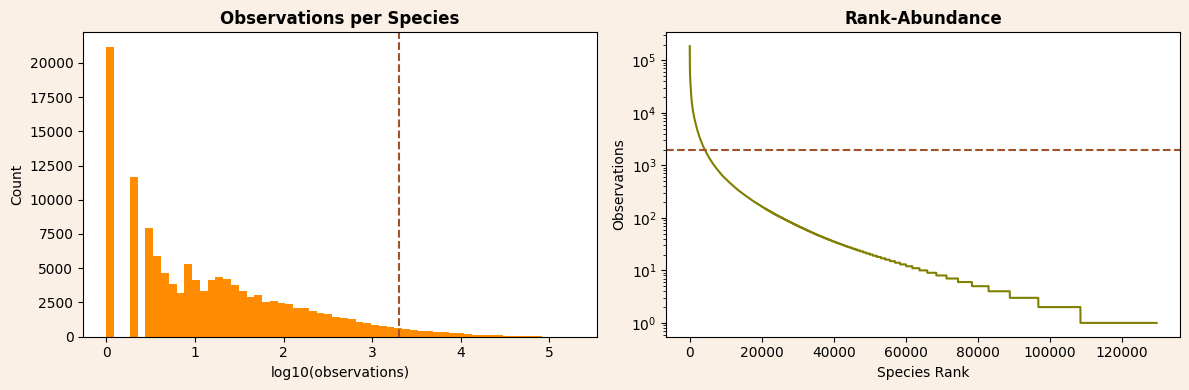

In [6]:
# long tail: few common species, most rarely observed
fig,axs = plt.subplots(1,2,figsize=(12,4))
fig.set_facecolor("linen")

axs[0].hist(np.log10(sp["numberOfOccurrences"]),bins=60,color="darkorange")
axs[0].axvline(np.log10(2000),color="sienna",ls="--")
axs[0].set_xlabel("log10(observations)")
axs[0].set_ylabel("Count")
axs[0].set_title("Observations per Species",weight="bold")

ranked = sp["numberOfOccurrences"].sort_values(ascending=False).values
axs[1].plot(ranked,color="olive")
axs[1].axhline(2000,color="sienna",ls="--")
axs[1].set_yscale("log")
axs[1].set_xlabel("Species Rank")
axs[1].set_ylabel("Observations")
axs[1].set_title("Rank-Abundance",weight="bold")
plt.tight_layout()
plt.show()

In [7]:
# species clearing each observation threshold
for t in (500,1000,2000,5000,10000):
    print(f">= {t:>6}: {(sp['numberOfOccurrences']>=t).sum():>6} species")

>=    500:  10626 species
>=   1000:   6771 species
>=   2000:   4172 species
>=   5000:   1983 species
>=  10000:    992 species


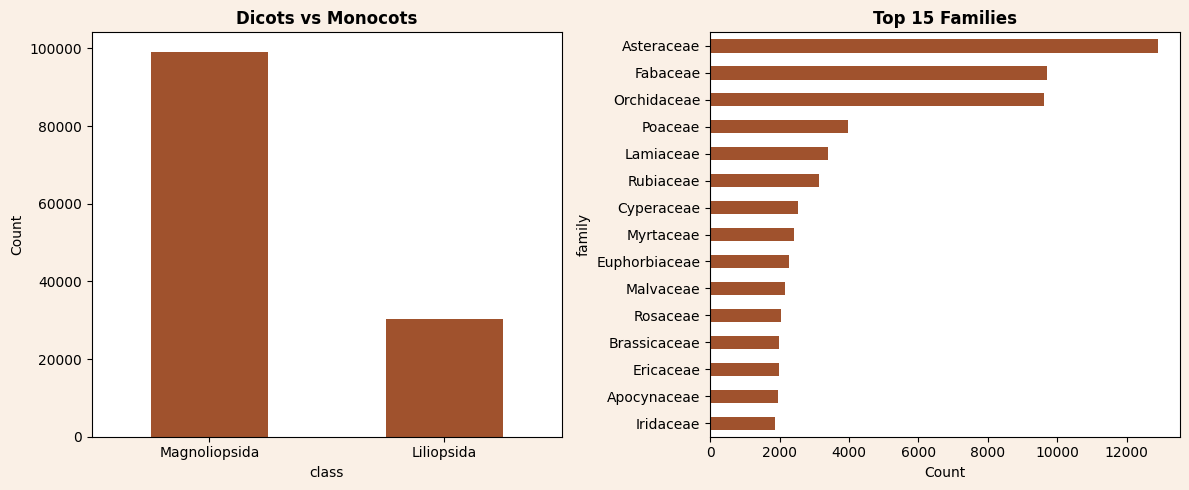

In [8]:
fig,axs = plt.subplots(1,2,figsize=(12,5))
fig.set_facecolor("linen")

sp["class"].value_counts().plot.bar(ax=axs[0],color="sienna")
axs[0].set_ylabel("Count")
axs[0].set_title("Dicots vs Monocots",weight="bold")
axs[0].tick_params(axis="x",rotation=0)

sp["family"].value_counts().head(15).iloc[::-1].plot.barh(ax=axs[1],color="sienna")
axs[1].set_xlabel("Count")
axs[1].set_title("Top 15 Families",weight="bold")
plt.tight_layout()
plt.show()

In [9]:
# select every species with >= 2000 observations
MIN_OBS = 2000
selected = sp[sp["numberOfOccurrences"]>=MIN_OBS].sort_values("numberOfOccurrences",ascending=False).reset_index(drop=True)

print(len(selected), "species")
print(selected["numberOfOccurrences"].min(), "-", selected["numberOfOccurrences"].max(), "obs")
print(selected["family"].nunique(), "families")
print(selected["class"].value_counts().to_string())
selected.head(10)[["species","family","numberOfOccurrences","speciesKey"]]

4172 species
2000 - 186173 obs
231 families
class
Magnoliopsida    3456
Liliopsida        716


,species,family,numberOfOccurrences,speciesKey
0,Achillea millefolium,Asteraceae,186173,3120060
1,Trifolium repens,Fabaceae,176681,5358748
2,Trifolium pratense,Fabaceae,166193,8324121
3,Alliaria petiolata,Brassicaceae,159299,5376075
4,Glechoma hederacea,Lamiaceae,146518,2926557
5,Plantago lanceolata,Plantaginaceae,136207,8208358
6,Ficaria verna,Ranunculaceae,128129,9094061
7,Prunella vulgaris,Lamiaceae,127043,5341297
8,Acer negundo,Sapindaceae,126327,3189866
9,Taraxacum officinale,Asteraceae,122776,5394163


In [10]:
cols = ["speciesKey","species","scientificName","genus","family","order","class","numberOfOccurrences","iucnRedListCategory"]
selected[cols].to_csv("../data/selected_species.csv",index=False)
print("wrote", len(selected), "species")

wrote 4172 species
